In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.utils.prune as prune
import torchvision.models as models

import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

from torch.optim.lr_scheduler import CosineAnnealingLR

In [2]:
# onnxファイルを作成する関数
def model_to_onnx(model, output_file, input_shape = (1, 3, 224, 224)):
  model.eval()
  input_tensor = torch.randn(input_shape).to('cpu')
  input_names = ['input']
  output_names = ['output']
  torch.onnx.export(model, input_tensor, output_file, verbose = False, input_names = input_names, output_names = output_names)
  return output_file

In [3]:
# モデル読み込み
pt_model_path = "dense.pt"
model = models.resnet18(weights = "IMAGENET1K_V1")
model.fc = nn.Linear(model.fc.in_features, 10)  # CIFAR-10 にあわせて出力層変更
model.load_state_dict(torch.load(pt_model_path))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [4]:
# 訓練データセット作成
transform = transforms.Compose([transforms.Resize(224),
                                transforms.ToTensor(),
                                transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])   # 正規化したほうがいいらしい

trainset = torchvision.datasets.CIFAR10(root = "./data", train = True, download = True, transform = transform)
trainloader = DataLoader(trainset, batch_size = 400, shuffle = True)

In [5]:
# 枝刈り前のTVを見てみる

def Omega(delta):
    """
    4階テンソルdeltaの各次元に沿った差分を計算し、
    その絶対値の総和を返す。
    """
    h = 1.0  # Dのパラメータ

    # 4つの次元それぞれに対して差分（勾配）を計算

    # dim=0 (出力チャネル方向の差分)
    diff_dim0 = delta[1:, :, :, :] - delta[:-1, :, :, :]

    # dim=1 (入力チャネル方向の差分)
    diff_dim1 = delta[:, 1:, :, :] - delta[:, :-1, :, :]

    # dim=2 (縦方向の差分)
    # 1行目から最後までと、0行目から最後の一つ手前までの差
    diff_dim2 = delta[:, :, 1:, :] - delta[:, :, :-1, :]

    # dim=3 (横方向の差分)
    # 1列目から最後までと、0列目から最後の一つ手前までの差
    diff_dim3 = delta[:, :, :, 1:] - delta[:, :, :, :-1]

    # 全ての差分の絶対値の総和を計算
    # これがD@deltaに相当する操作のL1ノルムになる
    constrain = torch.sum(torch.abs(diff_dim0)) + torch.sum(torch.abs(diff_dim1)) + torch.sum(torch.abs(diff_dim2)) + torch.sum(torch.abs(diff_dim3))

    return constrain / h

layer_tvs = {}
layer_relative_tvs = {}
conv_layer_names = []

for name, module in model.named_modules():
    if isinstance(module, nn.Conv2d):
        w_tensor = module.weight.detach().clone().to(device)
        tv = Omega(w_tensor).item()
        ave_tv = tv/(w_tensor).numel()
        relative_tv = tv / torch.sum(torch.abs(w_tensor)).item()
        layer_tvs[name] = tv
        layer_relative_tvs[name] = relative_tv
        conv_layer_names.append(name)
        print(f"{name}：TV={tv:.4f}     ave_TV={ave_tv:.4f}     relative_TV={relative_tv:.4f}")

conv1：TV=2785.1948     ave_TV=0.2960     relative_TV=3.8864
layer1.0.conv1：TV=5368.6899     ave_TV=0.1456     relative_TV=4.6001
layer1.0.conv2：TV=5110.8359     ave_TV=0.1386     relative_TV=4.3279
layer1.1.conv1：TV=5665.4883     ave_TV=0.1537     relative_TV=4.4829
layer1.1.conv2：TV=5081.4331     ave_TV=0.1378     relative_TV=4.3692
layer2.0.conv1：TV=9606.8564     ave_TV=0.1303     relative_TV=4.4254
layer2.0.conv2：TV=15700.7480     ave_TV=0.1065     relative_TV=4.4383
layer2.0.downsample.0：TV=1077.2024     ave_TV=0.1315     relative_TV=2.9591
layer2.1.conv1：TV=16048.6338     ave_TV=0.1088     relative_TV=4.4778
layer2.1.conv2：TV=14007.5215     ave_TV=0.0950     relative_TV=4.2592
layer3.0.conv1：TV=24442.1191     ave_TV=0.0829     relative_TV=3.9467
layer3.0.conv2：TV=45506.3359     ave_TV=0.0772     relative_TV=4.1868
layer3.0.downsample.0：TV=2261.6729     ave_TV=0.0690     relative_TV=2.8949
layer3.1.conv1：TV=41485.1523     ave_TV=0.0703     relative_TV=4.2055
layer3.1.conv2：TV=37498

In [6]:
# すべての畳み込み層を枝刈り対象に
parameters_to_prune = [
    (module, "weight") for module in model.modules() if isinstance(module, torch.nn.Conv2d)
]

# 大域的・非構造・強度枝刈り
cut_rate = 0.8
prune.global_unstructured(
    parameters_to_prune,
    pruning_method = prune.L1Unstructured,
    amount = cut_rate,
)

In [7]:
# ゼロ比率を表示
zero_ratings = {}
for name, module in model.named_modules():
  if isinstance(module, torch.nn.Conv2d):
    zero_ratings[name] = float(torch.sum(module.weight == 0)) / float(module.weight.nelement())
    print(f"{name} Zero-Ratio: {100.0 * zero_ratings[name]:.2f}%")

conv1 Zero-Ratio: 38.31%
layer1.0.conv1 Zero-Ratio: 55.09%
layer1.0.conv2 Zero-Ratio: 49.67%
layer1.1.conv1 Zero-Ratio: 47.75%
layer1.1.conv2 Zero-Ratio: 49.55%
layer2.0.conv1 Zero-Ratio: 53.27%
layer2.0.conv2 Zero-Ratio: 60.93%
layer2.0.downsample.0 Zero-Ratio: 41.87%
layer2.1.conv1 Zero-Ratio: 60.06%
layer2.1.conv2 Zero-Ratio: 62.14%
layer3.0.conv1 Zero-Ratio: 65.52%
layer3.0.conv2 Zero-Ratio: 70.63%
layer3.0.downsample.0 Zero-Ratio: 60.38%
layer3.1.conv1 Zero-Ratio: 74.44%
layer3.1.conv2 Zero-Ratio: 77.11%
layer4.0.conv1 Zero-Ratio: 77.54%
layer4.0.conv2 Zero-Ratio: 82.73%
layer4.0.downsample.0 Zero-Ratio: 59.40%
layer4.1.conv1 Zero-Ratio: 80.54%
layer4.1.conv2 Zero-Ratio: 92.18%


In [8]:
# 強度枝刈り後のTVを見る

layer_tvs = {}
layer_relative_tvs = {}
conv_layer_names = []

for name, module in model.named_modules():
    if isinstance(module, nn.Conv2d):
        w_tensor = module.weight.detach().clone().to(device)
        tv = Omega(w_tensor).item()
        ave_tv = tv/(w_tensor).numel()
        relative_tv = tv / torch.sum(torch.abs(w_tensor)).item()
        layer_tvs[name] = tv
        layer_relative_tvs[name] = relative_tv
        conv_layer_names.append(name)
        print(f"{name}：TV={tv:.4f}     ave_TV={ave_tv:.4f}     relative_TV={relative_tv:.4f}")

conv1：TV=2746.3330     ave_TV=0.2919     relative_TV=3.9802
layer1.0.conv1：TV=5002.3647     ave_TV=0.1357     relative_TV=5.0000
layer1.0.conv2：TV=4723.6909     ave_TV=0.1281     relative_TV=4.7890
layer1.1.conv1：TV=5302.7500     ave_TV=0.1438     relative_TV=4.9324
layer1.1.conv2：TV=4684.8525     ave_TV=0.1271     relative_TV=4.8468
layer2.0.conv1：TV=8686.2734     ave_TV=0.1178     relative_TV=4.9516
layer2.0.conv2：TV=13414.9033     ave_TV=0.0910     relative_TV=5.1591
layer2.0.downsample.0：TV=1038.2271     ave_TV=0.1267     relative_TV=3.1837
layer2.1.conv1：TV=13776.7891     ave_TV=0.0934     relative_TV=5.1793
layer2.1.conv2：TV=11706.8945     ave_TV=0.0794     relative_TV=5.0190
layer3.0.conv1：TV=19754.8594     ave_TV=0.0670     relative_TV=4.6893
layer3.0.conv2：TV=34147.1719     ave_TV=0.0579     relative_TV=5.1229
layer3.0.downsample.0：TV=1928.5745     ave_TV=0.0589     relative_TV=3.3566
layer3.1.conv1：TV=28916.0195     ave_TV=0.0490     relative_TV=5.2526
layer3.1.conv2：TV=24691

In [9]:
import json

# 辞書をJSONファイルに書き出す
with open('80cut_data.json', 'w') as f:
    json.dump(zero_ratings, f, indent=4) # indent=4できれいに整形

with open('80cut_TV.json', 'w') as f:
    json.dump(layer_tvs, f, indent=4)

print("辞書を '90cut_data.json' に保存しました。")
print("辞書を '90cut_relativeTV.json' に保存しました。")

辞書を '90cut_data.json' に保存しました。
辞書を '90cut_relativeTV.json' に保存しました。


In [10]:
# 再訓練
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)   #lr = 0.001で損失0.02とか
num_epochs = 15
epoch_loss_list = []
# CosineAnnealingLRを定義
# T_max: 学習率が半周期で最小値になるまでのエポック数。通常、総エポック数を指定。
# eta_min: 最小学習率。
scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=0)

for epoch in range(num_epochs):
  model.train()
  model = model.to(device)
  total_loss = 0.0
  num_train = 0
  for inputs, labels in trainloader:
    inputs, labels = inputs.to(device), labels.to(device)   # データ代入

    # 重み更新のための手順
    optimizer.zero_grad()
    outputs = model(inputs)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

    # 損失を記録
    total_loss += loss.item()*labels.size(0)
    num_train+=labels.size(0)

  # 出力と記録
  epoch_loss_list.append(total_loss/num_train)
  current_lr = optimizer.param_groups[0]['lr']
  print(f'Epoch[{epoch+1}/{num_epochs}], Loss: {epoch_loss_list[epoch]:.4f}, LR: {current_lr:.8f}')


  # 次のエポックへの準備
  if epoch >= 1:
    if np.abs(epoch_loss_list[epoch]-epoch_loss_list[epoch-1]) < 0.001:
      break
  scheduler.step()

Epoch[1/15], Loss: 0.4109, LR: 0.00100000
Epoch[2/15], Loss: 0.1451, LR: 0.00098907
Epoch[3/15], Loss: 0.0708, LR: 0.00095677
Epoch[4/15], Loss: 0.0319, LR: 0.00090451
Epoch[5/15], Loss: 0.0130, LR: 0.00083457
Epoch[6/15], Loss: 0.0041, LR: 0.00075000
Epoch[7/15], Loss: 0.0016, LR: 0.00065451
Epoch[8/15], Loss: 0.0010, LR: 0.00055226


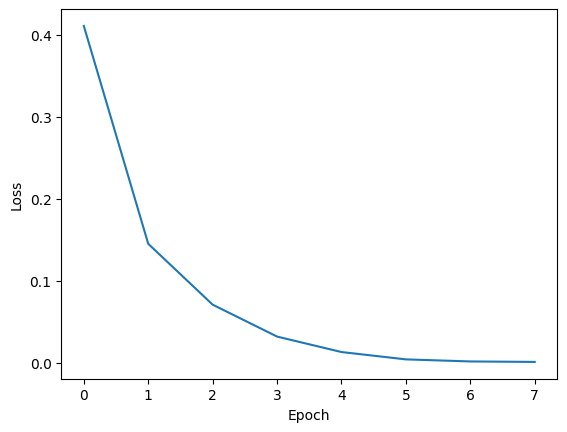

In [11]:
# 損失グラフ作成
plt.plot(epoch_loss_list)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

In [12]:
# 永続化（マスクと重みを掛ける）
for module in model.modules():
  if isinstance(module, torch.nn.Conv2d):
    prune.remove(module, "weight")

In [13]:
# onnxファイルとptファイルの作成
model = model.to('cpu')
model_to_onnx(model, "sparse_trained_95.onnx")
torch.save(model.state_dict(), "sparse_trained_95.pt")

In [ ]:
# 2. モデルの全てのモジュールを名前付きでループ
"""
for name, module in model.named_modules():

    # 3. モジュールが畳み込み層(nn.Conv2d)かどうかを判定
    if isinstance(module, nn.Conv2d):
        conv_weight = module.weight.data
        w_2d = conv_weight.view(conv_weight.size(0), -1).numpy()  # shape: [64, 3×7×7=147]

        # データの絶対値の最大値を取得
        vmax = np.abs(w_2d).max()
        plt.imshow(w_2d, cmap='seismic', aspect='auto', vmin = -vmax, vmax = vmax)
        plt.colorbar()
        plt.title(name)
        plt.show()
"""

In [ ]:
"""
# 2. モデルの全てのモジュールを名前付きでループ
for name, module in model.named_modules():

    # 3. モジュールが畳み込み層(nn.Conv2d)かどうかを判定
    if isinstance(module, nn.Conv2d):
        conv_weight = module.weight.data
        w_2d = conv_weight.view(conv_weight.size(0), -1).numpy()  # shape: [64, 3×7×7=147]

        # データの絶対値の最大値を取得
        vmax = np.abs(w_2d[:64, :147]).max()
        plt.imshow(w_2d, cmap='seismic', aspect='auto', vmin = -vmax, vmax = vmax)
        plt.colorbar()
        plt.title(name)
        plt.show()
"""